<a href="https://colab.research.google.com/github/prasanna-venkatesh-m/Analytics-Forecast/blob/main/SumofTotalPAR_Daily_Forecasting_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import numpy as np
import xgboost as xgb
from xgboost import XGBRegressor
import re
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [47]:
df = pd.read_csv('/content/lag_data.csv')

In [53]:
df['Date'] = pd.to_datetime(df['Date'])

grouped_df = df.groupby('Date').sum(numeric_only=True).reset_index()

print(grouped_df.head())

        Date  Unnamed: 0  BranchID  CountofGroup  CountofClientName  \
0 2023-03-31    13232664     11630          9764               9731   
1 2023-04-01    13232816     11630          9764               9731   
2 2023-04-02    13232968     11630          9764               9731   
3 2023-04-03    13233120     11630          9764               9731   
4 2023-04-04    13233272     11630          9764               9731   

   CountofAccountID  CountofCreditOfficerID  SumofPrincipalOutstanding  \
0              9764                    9764                  114244001   
1              9764                    9764                  114244001   
2              9764                    9764                  114244001   
3              9764                    9764                  114244001   
4              9764                    9764                  114244001   

   SumofInterestOutstanding  SumofTotalPrincipalOverdue  ...  \
0                  12599309                   106626416  ...   


/tmp/ipykernel_2412/2142040976.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [54]:
grouped_df['Date'] = pd.to_datetime(grouped_df['Date'])

grouped_df = grouped_df.sort_values('Date')

grouped_df['lag_1'] = grouped_df['SumofTotalPAR'].shift(1)
grouped_df['lag_2'] = grouped_df['SumofTotalPAR'].shift(2)
grouped_df['lag_3'] = grouped_df['SumofTotalPAR'].shift(3)
grouped_df['lag_7'] = grouped_df['SumofTotalPAR'].shift(7)
grouped_df['lag_14'] = grouped_df['SumofTotalPAR'].shift(14)
grouped_df['lag_30'] = grouped_df['SumofTotalPAR'].shift(30)

grouped_df['day'] = grouped_df['Date'].dt.day
grouped_df['month'] = grouped_df['Date'].dt.month
grouped_df['dayofweek'] = grouped_df['Date'].dt.dayofweek
grouped_df['weekofyear'] = grouped_df['Date'].dt.isocalendar().week.astype(int)

In [55]:
grouped_df['target_log'] = np.log1p(grouped_df['SumofTotalPAR'])
grouped_df = grouped_df.dropna().reset_index(drop=True)

In [58]:
features = [
    'SumofTotalPAR_7day_lag',
    'SumofTotalPAR_15day_lag',
    'SumofTotalPAR_30day_lag',
    'SumofTotalPAR_365day_lag',
    'day',
    'month',
    'dayofweek',
    'weekofyear'
]

grouped_df['Date'] = pd.to_datetime(grouped_df['Date'])

train_df = grouped_df[grouped_df['Date'] < '2026-04-01'].copy()
test_df = grouped_df[grouped_df['Date'] >= '2026-04-01'].copy()


In [59]:
X_train = train_df[features]
y_train = train_df['target_log']

X_test = test_df[features]
y_test = test_df['target_log']

In [66]:
model = XGBRegressor(
    n_estimators=10000,
    learning_rate=0.01,
    max_depth=5,
    random_state=42
)

In [67]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

Streaming output truncated to the last 5000 lines.
[5000]	validation_0-rmse:0.03925
[5001]	validation_0-rmse:0.03925
[5002]	validation_0-rmse:0.03925
[5003]	validation_0-rmse:0.03925
[5004]	validation_0-rmse:0.03925
[5005]	validation_0-rmse:0.03925
[5006]	validation_0-rmse:0.03925
[5007]	validation_0-rmse:0.03925
[5008]	validation_0-rmse:0.03925
[5009]	validation_0-rmse:0.03925
[5010]	validation_0-rmse:0.03925
[5011]	validation_0-rmse:0.03925
[5012]	validation_0-rmse:0.03925
[5013]	validation_0-rmse:0.03925
[5014]	validation_0-rmse:0.03925
[5015]	validation_0-rmse:0.03925
[5016]	validation_0-rmse:0.03925
[5017]	validation_0-rmse:0.03925
[5018]	validation_0-rmse:0.03925
[5019]	validation_0-rmse:0.03925
[5020]	validation_0-rmse:0.03925
[5021]	validation_0-rmse:0.03925
[5022]	validation_0-rmse:0.03925
[5023]	validation_0-rmse:0.03925
[5024]	validation_0-rmse:0.03925
[5025]	validation_0-rmse:0.03925
[5026]	validation_0-rmse:0.03925
[5027]	validation_0-rmse:0.03925
[5028]	validation_0-rmse:

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=10000,
             n_jobs=None, num_parallel_tree=None, ...)

In [68]:
preds = model.predict(X_test)

In [73]:
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

print("\n====================")
print("MODEL PERFORMANCE")
print("====================")
print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")


MODEL PERFORMANCE
MAE : 0.02
RMSE: 0.04
MAPE: 0.11%


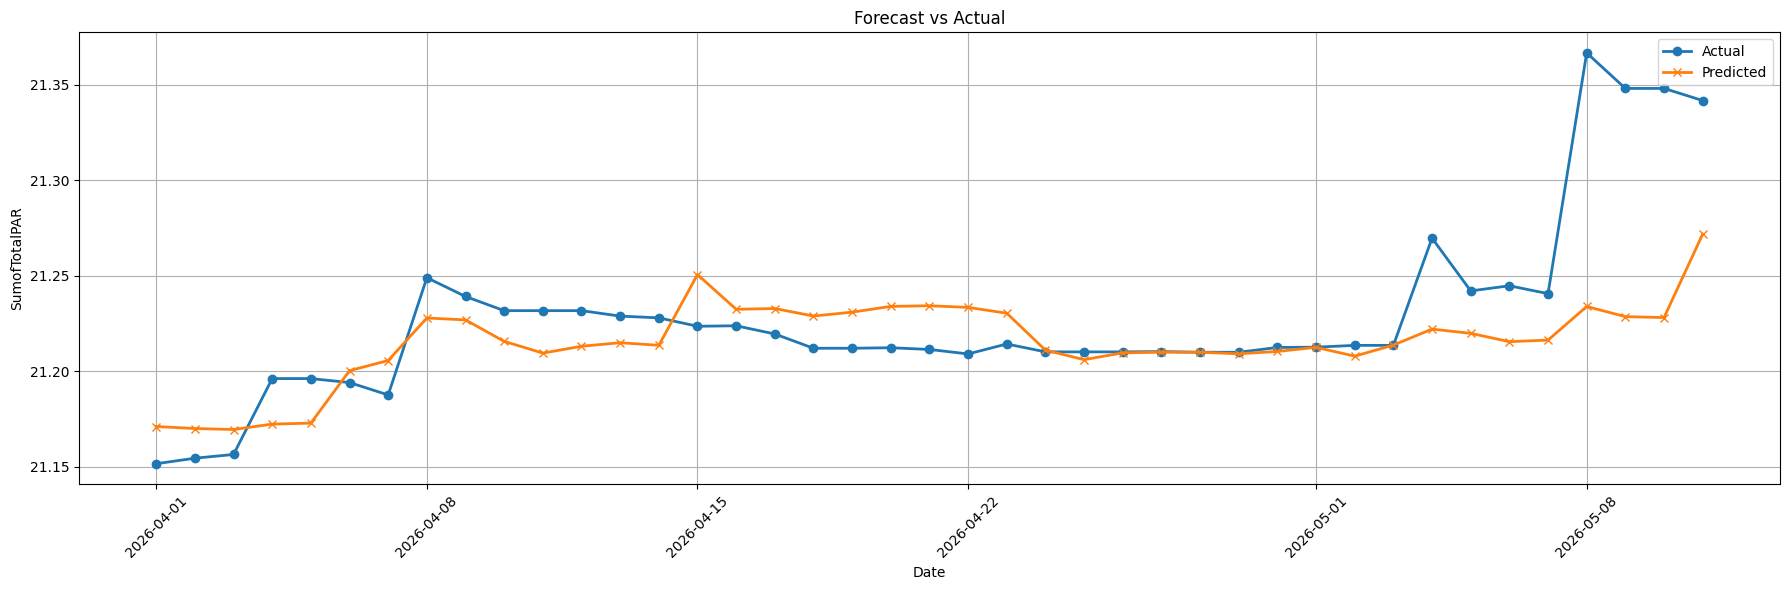

In [74]:
plt.figure(figsize=(18,6))

plt.plot(test_df['Date'], y_test, label='Actual', linewidth=2, marker='o')
plt.plot(test_df['Date'], preds, label='Predicted', linewidth=2, marker='x')

plt.title("Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("SumofTotalPAR")

plt.legend()
plt.grid()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


Feature Importance:
                    Feature  Importance
0    SumofTotalPAR_7day_lag    0.665035
2   SumofTotalPAR_30day_lag    0.181925
1   SumofTotalPAR_15day_lag    0.140944
3  SumofTotalPAR_365day_lag    0.007351
7                weekofyear    0.004249
5                     month    0.000456
4                       day    0.000033
6                 dayofweek    0.000008


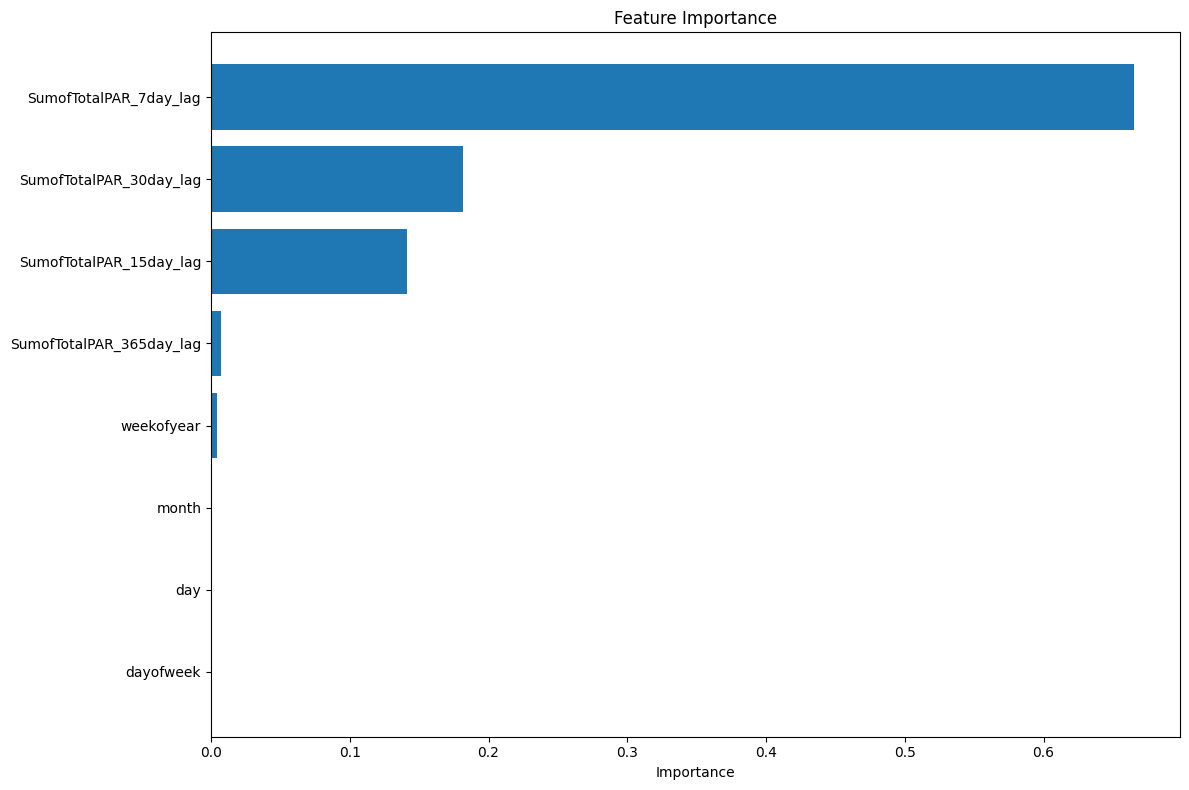

In [75]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance_df)

plt.figure(figsize=(12, 8))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.gca().invert_yaxis()

plt.title('Feature Importance')

plt.xlabel('Importance')

plt.tight_layout()

plt.show()